# 도로·하수 시계열 전처리 (eda_based)

> `flood_flag=level>0` 폐기 후, **시계열 전처리 원칙**으로 도로·하수 센서를 재정의한다.  
> 설계 문서: `TIMESERIES_PREPROCESSING_DESIGN.md` · 데이터품질: `DATA_QUALITY_FINDINGS.md`

**파이프라인**: 도로 품질등급(baseline) → 도로 정제 → stuck 분석 → 도로 10분 패널 → 하수 피처 → 시각화

원칙: 원본 보존 · 마스크 중심 결측 · 차분 피처 · stuck 구간플래그(≥1day) · 10분 해상도 · 누수 방지


## 0. 설정 (imports · 경로 · 한글폰트)


In [20]:
import pandas as pd, numpy as np, glob, os
import matplotlib; import matplotlib.font_manager as fm
korf=next((c for c in ['NanumGothic','Malgun Gothic','AppleGothic','Noto Sans CJK KR','UnDotum']
           if c in {f.name for f in fm.fontManager.ttflist}), None)
if korf: matplotlib.rcParams['font.family']=korf
matplotlib.rcParams['axes.unicode_minus']=False
import matplotlib.pyplot as plt

RAW_ROAD ='./dataset/processed/raw_parquet/road/*.parquet'   # 변환본(=원본 검증완료)
RAW_SEWER='./dataset/processed/raw_parquet/sewer/*.parquet'
OUT='./dataset/processed/eda_based/'; os.makedirs(OUT,exist_ok=True)
VIZ='./dataset/processed/viz/'; os.makedirs(VIZ,exist_ok=True)
ERR={312,419,999,1000}; SAT=96; TRAIN_END=pd.Timestamp('2025-01-01')
print('한글폰트:', korf)


한글폰트: NanumGothic


## 1. 도로 센서 품질 + baseline  →  `road_sensor_quality.parquet`
센서별 통계(결측·stuck·saturation·p99)로 **A/B/C 등급**을 매기고, train 기준 **baseline**(최빈·q10)을 구한다.
- C = 만성 saturation(sat96≥0.5%) · 결측>50% · 극단값>1%
- B = stuck 의심 또는 level_one 비율 큼 · A = 사용가능
- baseline은 누수 방지 위해 **train(2024)에서만** fit

> ⚠️ raw 44/24개 파일 순회 — 수 분 소요. 이미 생성됐으면 다음 시각화 셀로.


In [ ]:
# ── Pass 1: 센서별 value_counts(전체/train) + 시간정보 ──
vcs_all=[]; vcs_tr=[]; tinfos=[]
for f in sorted(glob.glob(RAW_ROAD)):
    df=pd.read_parquet(f,columns=['sensor_id','timestamp','level']); df['timestamp']=pd.to_datetime(df['timestamp'])
    vcs_all.append(df.groupby('sensor_id')['level'].value_counts())
    tr=df[df['timestamp']<TRAIN_END]
    if len(tr): vcs_tr.append(tr.groupby('sensor_id')['level'].value_counts())
    tinfos.append(df.groupby('sensor_id')['timestamp'].agg(t0='min',t1='max',n='size'))
vc_all=pd.concat(vcs_all).groupby(level=[0,1]).sum()
vc_tr =pd.concat(vcs_tr ).groupby(level=[0,1]).sum()
tinfo =pd.concat(tinfos).groupby(level=0).agg(t0=('t0','min'),t1=('t1','max'),n=('n','sum'))

def wq(s,q):  # value_counts(index=level)에서 가중 백분위
    s=s.sort_index(); cum=s.cumsum(); tot=s.sum(); return float(s.index[(cum>=q*tot).values.argmax()])

rows=[]
for sid in tinfo.index:
    va=vc_all.loc[sid]; tot=va.sum()
    valid=va[(~va.index.isin(ERR))&(va.index!=SAT)&(va.index>=0)]
    vt=vc_tr.loc[sid] if sid in vc_tr.index.get_level_values(0) else va
    vtv=vt[(~vt.index.isin(ERR))&(vt.index!=SAT)&(vt.index>=0)]
    b_mode=float(vtv.idxmax()) if len(vtv) else 0.0; b_q10=wq(vtv,0.10) if len(vtv) else 0.0
    span=(tinfo.loc[sid,'t1']-tinfo.loc[sid,'t0']).total_seconds()/60+1
    top=va.sort_values(ascending=False)
    rows.append(dict(sensor_id=sid,n_obs=int(tot),t0=tinfo.loc[sid,'t0'],t1=tinfo.loc[sid,'t1'],
        missing_pct=max(0,(1-tinfo.loc[sid,'n']/span))*100,
        zero_pct=va.get(0,0)/tot*100, level_one_pct=va.get(1,0)/tot*100,
        sat96_pct=va.get(96,0)/tot*100, extreme_pct=va[va.index>=999].sum()/tot*100,
        unique_cnt=int((va>0).sum()), top3_pct=top.head(3).sum()/tot*100,
        max_level=float(va.index.max()), p99_valid=wq(valid,0.99) if len(valid) else 0.0,
        baseline=min(b_mode,b_q10)))
q=pd.DataFrame(rows).set_index('sensor_id')

# 등급: chronic saturation = sat96_pct>=0.5  (p99는 96 제외값이라 saturation은 sat96_pct로 직접)
q['is_chronic_sat']=q['sat96_pct']>=0.5
q['is_stuck']=(q['top3_pct']>=80)&(q['unique_cnt']<=5)&((100-q['zero_pct'])>5)
q['grade']=np.where(q['is_chronic_sat']|(q['missing_pct']>50)|(q['extreme_pct']>1),'C',
            np.where(q['is_stuck']|(q['level_one_pct']>20),'B','A'))
q.to_parquet(OUT+'road_sensor_quality.parquet')
print('등급:', q['grade'].value_counts().to_dict(), '| 침수-prone(p99>=6):', int((q['p99_valid']>=6).sum()))


## 2. 도로 정제  →  `road_cleaned.parquet`
행별 품질 플래그 + level_clean(오류·saturation NaN) + baseline + level_adj. **원본 level_raw는 보존.**
- `level_clean = NaN if (96 saturation | ≥999 | 312/419/음수) else level_raw`
- `level_adj = max(level_clean − baseline, 0)`
> ⚠️ 56M행 출력(약 415MB) — 수 분 소요.


In [ ]:
import pyarrow as pa, pyarrow.parquet as pq
base=q['baseline'].to_dict(); grade=q['grade'].to_dict(); INVALID={312,419}
schema=pa.schema([('sensor_id',pa.string()),('timestamp',pa.timestamp('ns')),
    ('level_raw',pa.float64()),('level_clean',pa.float64()),('sensor_baseline',pa.float64()),
    ('level_adj',pa.float64()),('is_zero',pa.int8()),('is_level_one',pa.int8()),
    ('is_saturated_96',pa.int8()),('is_extreme_ge_999',pa.int8()),('is_invalid_level',pa.int8()),('grade',pa.string())])
w=pq.ParquetWriter(OUT+'road_cleaned.parquet',schema); tot=0
for f in sorted(glob.glob(RAW_ROAD)):
    df=pd.read_parquet(f,columns=['sensor_id','timestamp','level']).rename(columns={'level':'level_raw'})
    df['timestamp']=pd.to_datetime(df['timestamp']); lv=df['level_raw']
    df['is_zero']=(lv==0).astype('int8'); df['is_level_one']=(lv==1).astype('int8')
    df['is_saturated_96']=(lv==96).astype('int8'); df['is_extreme_ge_999']=(lv>=999).astype('int8')
    df['is_invalid_level']=(lv.isin(INVALID)|(lv<0)).astype('int8')
    bad=(df['is_saturated_96']|df['is_extreme_ge_999']|df['is_invalid_level']).astype(bool)
    df['level_clean']=lv.where(~bad,np.nan)
    df['sensor_baseline']=df['sensor_id'].map(base).fillna(0.0)
    df['level_adj']=(df['level_clean']-df['sensor_baseline']).clip(lower=0)
    df['grade']=df['sensor_id'].map(grade).fillna('?')
    w.write_table(pa.Table.from_pandas(df[[s.name for s in schema]],schema=schema,preserve_index=False)); tot+=len(df)
w.close(); print(f'road_cleaned 저장: {tot:,}행')


## 3. stuck run-length 분석 → 임계 결정
동일값 연속(run)의 시간 길이 분포로 stuck 임계를 **데이터로** 정한다 (0 제외, 비영점만).
결과(2026-06-17): 도로는 1d+ run이 비영점 시간의 97.5% → **stuck = ≥1day** 로 확정 (추측 60분/6시간 폐기).


In [ ]:
# 도로 비영점 동일값 run의 시간길이 분포 (raw 기준)
bins=[0,5,30,60,360,720,1440,1e9]; labs=['0-5m','5-30m','30-60m','1-6h','6-12h','12-24h','1d+']
cnt=np.zeros(len(bins)-1); tw=np.zeros(len(bins)-1)
for f in sorted(glob.glob(RAW_ROAD)):
    df=pd.read_parquet(f,columns=['sensor_id','timestamp','level']); df['timestamp']=pd.to_datetime(df['timestamp'])
    df=df[(df['level'].notna())&(df['level']>0)&(~df['level'].isin(ERR|{SAT}))].sort_values(['sensor_id','timestamp'])
    sid=df['sensor_id'].values; lv=df['level'].values
    chg=np.ones(len(df),bool); chg[1:]=(sid[1:]!=sid[:-1])|(lv[1:]!=lv[:-1]); rid=chg.cumsum()
    span=(df.groupby(rid)['timestamp'].max()-df.groupby(rid)['timestamp'].min()).dt.total_seconds().values/60
    cnt+=np.histogram(span,bins)[0]; tw+=np.histogram(span,bins,weights=span)[0]
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].bar(labs,cnt/cnt.sum()*100,color='steelblue'); ax[0].set_title('도로 run 개수 분포(%)'); ax[0].tick_params(axis='x',rotation=30)
ax[1].bar(labs,tw/tw.sum()*100,color='crimson'); ax[1].set_title('도로 run 시간가중 분포(%) — 1d+가 stuck'); ax[1].tick_params(axis='x',rotation=30)
plt.tight_layout(); plt.savefig(VIZ+'stuck_runlength_road.png',dpi=110); plt.show()
print('시간가중 1d+ 비율:', round(tw[-1]/tw.sum()*100,1),'%  → stuck 임계 ≥1day')


## 4. 도로 10분 패널 (시계열 원칙)  →  `road_panel_10min.parquet`
stuck 구간플래그(≥1day) + 10분 집계 + **지속시간(dur_ge T)** + **차분(갭 존중)** + 마스크.
- `dur_ge2/6/10` = 10분 중 level≥T인 분 수 → '잠깐 튄 값 vs 지속' 구분
- `level_diff` = 10분 차분, **직전 빈이 정확히 10분 전일 때만**(갭 너머 NaN)
- `stuck_frac` = 빈 내 stuck 구간 비율


In [ ]:
rc=pd.read_parquet(OUT+'road_cleaned.parquet',columns=['sensor_id','timestamp','level_clean','level_adj','grade'])
rc['timestamp']=pd.to_datetime(rc['timestamp']); rc=rc.sort_values(['sensor_id','timestamp']).reset_index(drop=True)
# stuck 구간 (비영점 동일값 ≥1day) — 벡터화
lv=rc['level_clean'].values; sid=rc['sensor_id'].values
ts=rc['timestamp'].values.astype('datetime64[s]').astype(np.int64)
chg=np.ones(len(rc),bool); chg[1:]=(sid[1:]!=sid[:-1])|(lv[1:]!=lv[:-1]); rid=np.cumsum(chg)-1
st=np.flatnonzero(chg); en=np.append(st[1:]-1,len(rc)-1)
stuck_run=((ts[en]-ts[st])/60.0>=1440)&(lv[st]>0); rc['is_stuck_seg']=stuck_run[rid].astype('int8')
# 10분 집계
rc['ts10']=rc['timestamp'].dt.floor('10min')
for T in (2,6,10): rc[f'ge{T}']=(rc['level_clean']>=T)
agg=rc.groupby(['sensor_id','ts10']).agg(road_max=('level_clean','max'),road_mean=('level_clean','mean'),
    road_adj_max=('level_adj','max'),n_valid=('level_clean','count'),grade=('grade','first'),
    stuck_frac=('is_stuck_seg','mean'),dur_ge2=('ge2','sum'),dur_ge6=('ge6','sum'),dur_ge10=('ge10','sum')).reset_index()
agg['is_missing']=(agg['n_valid']==0).astype('int8')
# 차분 (갭 존중)
agg=agg.sort_values(['sensor_id','ts10']); prev=agg.groupby('sensor_id')['ts10'].shift(1)
gap_ok=((agg['ts10']-prev).dt.total_seconds()/60==10)
agg['level_diff']=agg.groupby('sensor_id')['road_max'].diff().where(gap_ok)
agg.to_parquet(OUT+'road_panel_10min.parquet',index=False)
print(f'road_panel_10min 저장: {len(agg):,}행 | stuck런 {int(stuck_run.sum())}개 | dur_ge6>0 빈 {int((agg.dur_ge6>0).sum())}')


## 5. 하수 피처 (10분)  →  `sewer_features_10min.parquet`
하수는 연속 기저유량 → 10분 mean/max/min/last + 차분 + rolling. (surcharge용 fill_rate는 다음 단계에서 추가 예정)
> ⚠️ 512M행 — 수 분 소요.


In [21]:
parts=[]
for f in sorted(glob.glob(RAW_SEWER)):
    df=pd.read_parquet(f,columns=['sensor_id','timestamp','level']); df['timestamp']=pd.to_datetime(df['timestamp'])
    df['ts10']=df['timestamp'].dt.floor('10min')
    parts.append(df.groupby(['sensor_id','ts10'])['level'].agg(m='mean',mx='max',mn='min',lt='last').reset_index())
sew=pd.concat(parts,ignore_index=True).groupby(['sensor_id','ts10']).agg(
    level_mean_10m=('m','mean'),level_max_10m=('mx','max'),level_min_10m=('mn','min'),level_last_10m=('lt','last')).reset_index()
sew=sew.sort_values(['sensor_id','ts10']); g=sew.groupby('sensor_id')['level_mean_10m']
sew['level_diff_10m']=g.diff()
for w,n in [('1h',6),('3h',18),('6h',36)]: sew[f'level_roll_{w}_mean']=g.rolling(n,min_periods=1).mean().reset_index(level=0,drop=True)
sew.rename(columns={'sensor_id':'sewer_sensor_id'}).to_parquet(OUT+'sewer_features_10min.parquet',index=False)
print(f'sewer_features 저장: {len(sew):,}행')


sewer_features 저장: 51,560,086행


## 6. 시각화 (저장된 산출물 로드 → 그림)
위 생성이 끝났으면(또는 이미 있으면) 아래로 결과를 확인. 빠르게 실행됨.


In [ ]:
q=pd.read_parquet(OUT+'road_sensor_quality.parquet')
panel=pd.read_parquet(OUT+'road_panel_10min.parquet')

fig,ax=plt.subplots(2,2,figsize=(14,9))
# (a) 도로 10분 road_max 분포 (이산 게이지)
vc=panel.loc[panel['road_max']>0,'road_max'].round().value_counts().sort_index().head(20)
ax[0,0].bar(vc.index.astype(str),vc.values,color='steelblue'); ax[0,0].set_yscale('log')
ax[0,0].set_title('도로 10분 road_max 분포 (>0, log)'); ax[0,0].set_xlabel('cm'); ax[0,0].tick_params(axis='x',rotation=90)
# (b) 센서 등급
gc=q['grade'].value_counts()
ax[0,1].bar(gc.index,gc.values,color=['#2a8','#c84','#c44']); ax[0,1].set_title('센서 품질 등급 (A/B/C)')
for i,v in enumerate(gc.values): ax[0,1].text(i,v,str(v),ha='center',va='bottom')
# (c) 센서별 p99 (침수-prone 식별)
ax[1,0].scatter(range(len(q)),q['p99_valid'].sort_values(ascending=False).values,s=12,color='crimson')
ax[1,0].axhline(6,ls='--',c='gray',label='p99=6 (침수-prone 기준)'); ax[1,0].legend()
ax[1,0].set_title('센서별 p99 수위 (내림차순) — 위쪽이 진짜 침수센서'); ax[1,0].set_xlabel('센서'); ax[1,0].set_ylabel('p99 cm')
# (d) 차분 분포 (0 제외)
d=panel['level_diff'].dropna(); d=d[d!=0]
ax[1,1].hist(d.clip(-30,30),bins=61,color='seagreen'); ax[1,1].set_yscale('log')
ax[1,1].set_title('도로 level_diff 분포 (0 제외, log) — 상승/하강'); ax[1,1].set_xlabel('Δcm/10min')
plt.tight_layout(); plt.savefig(VIZ+'road_domain_overview.png',dpi=110); plt.show()
print('등급:',gc.to_dict(),'| stuck_frac>0 빈:',round((panel.stuck_frac>0).mean()*100,1),'%')


---
### 산출물 (`dataset/processed/eda_based/`)
- `road_sensor_quality.parquet` · `road_cleaned.parquet` · `road_panel_10min.parquet` · `sewer_features_10min.parquet`
### 다음
- 하수 1급화: 품질등급 + **fill_rate/surcharge** + stuck 구간
- 라벨 생성(level≥T + 지속시간) → persistence 대비 nowcast 베이스라인


---
## 7. 하수 센서 품질 (1급화)  →  `sewer_sensor_quality.parquet`
하수는 연속 기저유량 → 도로와 다른 기준. status(미수신)와 flat_frac(diff=0 비율=stuck 대용)으로 등급.
- C = 미수신(통신장애) · B = flat_frac>70%(과도하게 변화없음=stuck 의심) · A = 사용가능
- 관 제원(`pipe_height_m`)으로 fill_rate 분모(capacity) 준비


In [22]:
sf=pd.read_parquet(OUT+'sewer_features_10min.parquet',
    columns=['sewer_sensor_id','level_mean_10m','level_max_10m','level_diff_10m'])
sf['is_flat']=(sf['level_diff_10m']==0)
g=sf.groupby('sewer_sensor_id')
sq=pd.DataFrame({'n_obs':g.size(),'level_med':g['level_mean_10m'].median(),
    'level_p99':g['level_mean_10m'].quantile(0.99),'level_max':g['level_max_10m'].max(),
    'flat_frac':g['is_flat'].mean()*100})
sn=pd.read_parquet('./dataset/processed/cleaned/sewer_node.parquet')[['sensor_id','status','pipe_height_m','hist_max_m']]
sq=sq.reset_index().rename(columns={'sewer_sensor_id':'sensor_id'}).merge(sn,on='sensor_id',how='left').set_index('sensor_id')
sq['capacity']=sq['pipe_height_m'].fillna(sq['hist_max_m']).fillna(2.0)   # fill_rate 분모(관높이, m)
sq['grade']=np.where(sq['status'].astype(str).str.contains('미수신',na=False),'C',
            np.where(sq['flat_frac']>70,'B','A'))
sq.to_parquet(OUT+'sewer_sensor_quality.parquet')
print('하수 등급:', sq['grade'].value_counts().to_dict())


하수 등급: {'A': 377, 'B': 95, 'C': 13}


## 8. 하수 정제 + surcharge 피처 (fill_rate)  →  `sewer_features_10min.parquet`

음수/측정범위 초과를 NaN 처리(정제)한 뒤 10분 재집계 → `fill_rate = level_max / 관높이`.
1에 가까울수록 만관(surcharge 임박). 정제로 **fill_rate 이상치 해소**, stuck 구간(≥1day)도 플래그.
> ⚠️ 512M행 — 수 분 소요. 도로 정제와 대칭(음수·측정범위 초과 제거 + stuck).


In [23]:
sn=pd.read_parquet('./dataset/processed/cleaned/sewer_node.parquet')[['sensor_id','pipe_height_m','hist_max_m','max_level_m']]
maxr=sn.set_index('sensor_id')['max_level_m'].fillna(20.0).to_dict()                 # 측정범위(over-range 기준)
cap=sn.set_index('sensor_id')['pipe_height_m'].fillna(sn.set_index('sensor_id')['hist_max_m']).fillna(2.0).clip(lower=0.3).to_dict()
parts=[]; neg=over=tot=0
for f in sorted(glob.glob(RAW_SEWER)):
    df=pd.read_parquet(f,columns=['sensor_id','timestamp','level']); df['timestamp']=pd.to_datetime(df['timestamp'])
    mr=df['sensor_id'].map(maxr).fillna(20.0); bneg=df['level']<0; bover=df['level']>mr
    neg+=int(bneg.sum()); over+=int(bover.sum()); tot+=len(df)
    df['lc']=df['level'].where(~(bneg|bover),np.nan); df['ts10']=df['timestamp'].dt.floor('10min')
    parts.append(df.groupby(['sensor_id','ts10'])['lc'].agg(m='mean',mx='max',mn='min',lt='last',nv='count').reset_index())
print(f"정제: 음수 {neg:,}+측정범위초과 {over:,} = {(neg+over)/tot*100:.3f}% NaN")
sew=pd.concat(parts,ignore_index=True).groupby(['sensor_id','ts10']).agg(
    level_mean_10m=('m','mean'),level_max_10m=('mx','max'),level_min_10m=('mn','min'),
    level_last_10m=('lt','last'),n_valid=('nv','sum')).reset_index().sort_values(['sensor_id','ts10'])
g=sew.groupby('sensor_id')['level_mean_10m']; sew['level_diff_10m']=g.diff()
for w,n in [('1h',6),('3h',18),('6h',36)]: sew[f'level_roll_{w}_mean']=g.rolling(n,min_periods=1).mean().reset_index(level=0,drop=True)
# stuck 구간 (10분 level_max 비영점 동일값 ≥1day=144스텝)
lv=sew['level_max_10m'].values; sid=sew['sensor_id'].values
chg=np.ones(len(sew),bool); chg[1:]=(sid[1:]!=sid[:-1])|(lv[1:]!=lv[:-1]); rid=np.cumsum(chg)-1
sew['is_stuck_seg']=((np.bincount(rid)[rid]>=144)&(lv>0)).astype('int8')
# fill_rate (정제된 level)
sew['capacity']=sew['sensor_id'].map(cap); sew['fill_rate']=sew['level_max_10m']/sew['capacity']
sew['fill_rate_diff']=sew.groupby('sensor_id')['fill_rate'].diff()
sew['is_surcharge']=(sew['fill_rate']>=1.0).astype('int8'); sew['is_near_surcharge']=(sew['fill_rate']>=0.8).astype('int8')
sew.rename(columns={'sensor_id':'sewer_sensor_id'}).to_parquet(OUT+'sewer_features_10min.parquet',index=False)
print("sewer_features(정제후):", sew.shape, "| fill_rate max:", round(sew['fill_rate'].max(),2), "| surcharge:", f"{sew['is_surcharge'].mean()*100:.3f}%")


정제: 음수 213,776+측정범위초과 25,429 = 0.047% NaN
sewer_features(정제후): (51560086, 17) | fill_rate max: 8.67 | surcharge: 0.178%


## 9. 하수 도메인 시각화


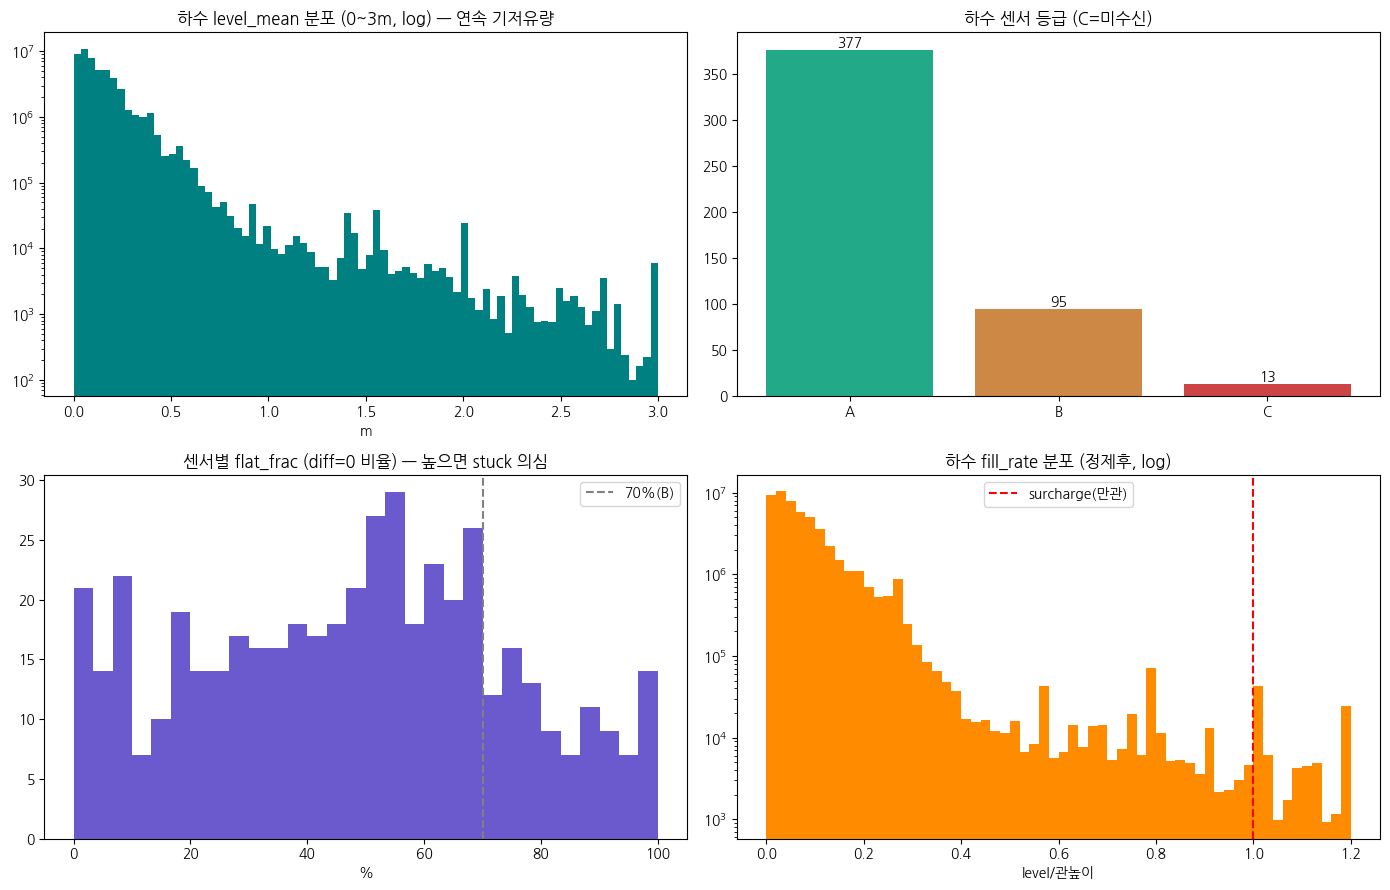

하수 등급: {'A': 377, 'B': 95, 'C': 13}


In [24]:
sq=pd.read_parquet(OUT+'sewer_sensor_quality.parquet')
sf2=pd.read_parquet(OUT+'sewer_features_10min.parquet',columns=['level_mean_10m','fill_rate'])  # 정제후: suspect 불필요
fig,ax=plt.subplots(2,2,figsize=(14,9))
# (a) 하수 level(m) 분포 — 연속 기저유량
lv=sf2['level_mean_10m'].dropna(); ax[0,0].hist(lv.clip(0,3),bins=80,color='teal'); ax[0,0].set_yscale('log')
ax[0,0].set_title('하수 level_mean 분포 (0~3m, log) — 연속 기저유량'); ax[0,0].set_xlabel('m')
# (b) 센서 등급
gc=sq['grade'].value_counts(); ax[0,1].bar(gc.index,gc.values,color=['#2a8','#c84','#c44'])
ax[0,1].set_title('하수 센서 등급 (C=미수신)')
for i,v in enumerate(gc.values): ax[0,1].text(i,v,str(v),ha='center',va='bottom')
# (c) flat_frac (stuck 대용)
ax[1,0].hist(sq['flat_frac'],bins=30,color='slateblue'); ax[1,0].axvline(70,ls='--',c='gray',label='70%(B)'); ax[1,0].legend()
ax[1,0].set_title('센서별 flat_frac (diff=0 비율) — 높으면 stuck 의심'); ax[1,0].set_xlabel('%')
# (d) fill_rate (정제후, 이상치 해소됨)
fr=sf2['fill_rate'].dropna()
ax[1,1].hist(fr.clip(0,1.2),bins=60,color='darkorange'); ax[1,1].axvline(1.0,ls='--',c='red',label='surcharge(만관)')
ax[1,1].set_yscale('log'); ax[1,1].legend(); ax[1,1].set_title('하수 fill_rate 분포 (정제후, log)'); ax[1,1].set_xlabel('level/관높이')
plt.tight_layout(); plt.savefig(VIZ+'sewer_domain_overview.png',dpi=110); plt.show()
print('하수 등급:',gc.to_dict())


---
### 하수 도메인 산출물
- `sewer_sensor_quality.parquet` (A/B/C) · `sewer_features_10min.parquet` (+fill_rate/surcharge)
### 남은 정제 (다음)
- **하수 정제**: 음수/측정범위 초과 제거 → fill_rate 이상치(>1.5) 해소
- 도로·하수 패널 조인(수리적/거리 페어링) · 라벨(level≥T) · persistence 대비 nowcast 베이스라인
